In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette="colorblind")

In [3]:
#! pip install sktime

# Quick example

In [4]:
from sktime.utils._testing.series import _make_series

y = _make_series(n_columns=1, n_timepoints=100, random_state=0)
y.head()

2000-01-01    5.317042
2000-01-02    3.953147
2000-01-03    4.531728
2000-01-04    5.793883
2000-01-05    5.420548
Freq: D, dtype: float64

In [5]:
y_train = y[:80]
y_test = y[80:]

In [6]:
from sktime.transformations.series.boxcox import BoxCoxTransformer

transformer = BoxCoxTransformer()

transformer.fit(y_train)

BoxCoxTransformer()

In [7]:
y_train_tr = transformer.transform(y_train)
y_train_tr.head()

2000-01-01    3.662162
2000-01-02    2.590946
2000-01-03    3.051525
2000-01-04    4.025894
2000-01-05    3.741539
Freq: D, dtype: float64

In [8]:
y_train_tr = transformer.fit_transform(y_train)
y_train_tr.head()

2000-01-01    3.662162
2000-01-02    2.590946
2000-01-03    3.051525
2000-01-04    4.025894
2000-01-05    3.741539
Freq: D, dtype: float64

In [9]:
y_test_tr = transformer.transform(y_test)
y_test_tr.head()

2000-03-21    1.283937
2000-03-22    2.990071
2000-03-23    2.643600
2000-03-24    0.956275
2000-03-25    3.449446
Freq: D, dtype: float64

In [10]:
y_test_inv = transformer.inverse_transform(y_test_tr)
y_test_inv.head()

2000-03-21    2.387840
2000-03-22    4.453816
2000-03-23    4.018652
2000-03-24    2.016746
2000-03-25    5.041242
Freq: D, dtype: float64

In [11]:
y_test.head()

2000-03-21    2.387840
2000-03-22    4.453816
2000-03-23    4.018652
2000-03-24    2.016746
2000-03-25    5.041242
Freq: D, dtype: float64

# Stationarising via differencing

In [12]:
from sktime.datasets.forecasting import Macroeconomic

df = Macroeconomic().load()[1]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 203 entries, 1959Q1 to 2009Q3
Freq: Q-DEC
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   realgdp   203 non-null    float64
 1   realcons  203 non-null    float64
 2   realinv   203 non-null    float64
 3   realgovt  203 non-null    float64
 4   realdpi   203 non-null    float64
 5   cpi       203 non-null    float64
 6   m1        203 non-null    float64
 7   tbilrate  203 non-null    float64
 8   unemp     203 non-null    float64
 9   pop       203 non-null    float64
 10  infl      203 non-null    float64
 11  realint   203 non-null    float64
dtypes: float64(12)
memory usage: 20.6 KB


In [14]:
from statsmodels.tsa.stattools import adfuller

adf_stat, pval, lags, obs, crit_vals, icbest = adfuller(df["unemp"], regression="n")
print(f"p-value: {pval:.3f}")

p-value: 0.629


In [15]:
from sktime.transformations.series.difference import Differencer

transformer = Differencer(lags=[1])
transformer.fit(df["unemp"])
df["unemp_diff"] = transformer.transform(df["unemp"])

df[["unemp", "unemp_diff"]].head()

,unemp,unemp_diff
Period,,
1959Q1,5.8,0.0
1959Q2,5.1,-0.7
1959Q3,5.3,0.2
1959Q4,5.6,0.3
1960Q1,5.2,-0.4


<Axes: xlabel='Period'>

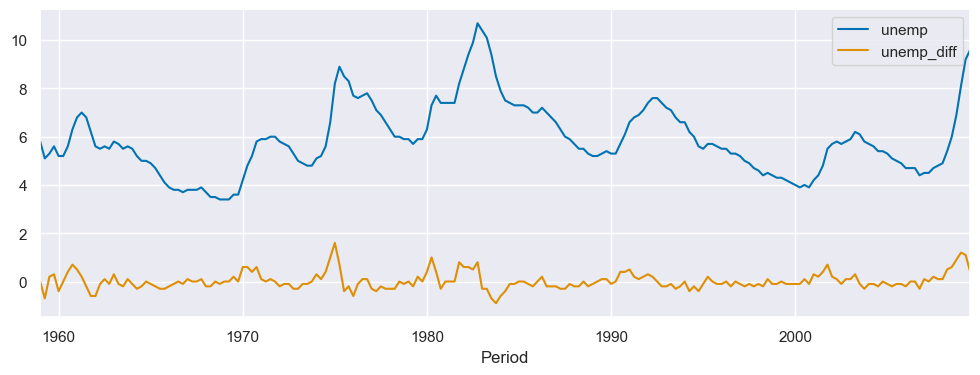

In [16]:
df[["unemp", "unemp_diff"]].plot(figsize=(12,4))

In [17]:
adf_stat, pval, lags, obs, crit_vals, icbest = adfuller(df["unemp_diff"], regression="n")
print(f"P-value: {pval:.3f}")

P-value: 0.000


<Axes: xlabel='Period'>

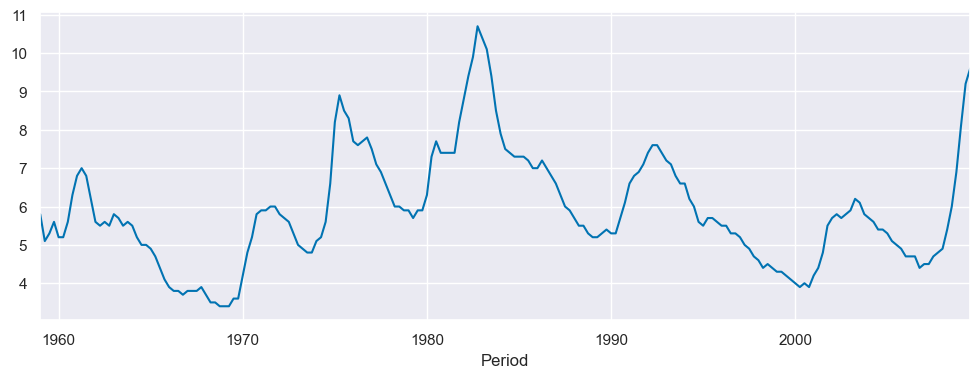

In [18]:
# inverse-transform
df["unemp_diff_invtransform"] = transformer.inverse_transform(df["unemp_diff"])
df["unemp_diff_invtransform"].plot(figsize=(12,4))

# Smoothing

## Log-transformation

<Axes: xlabel='y'>

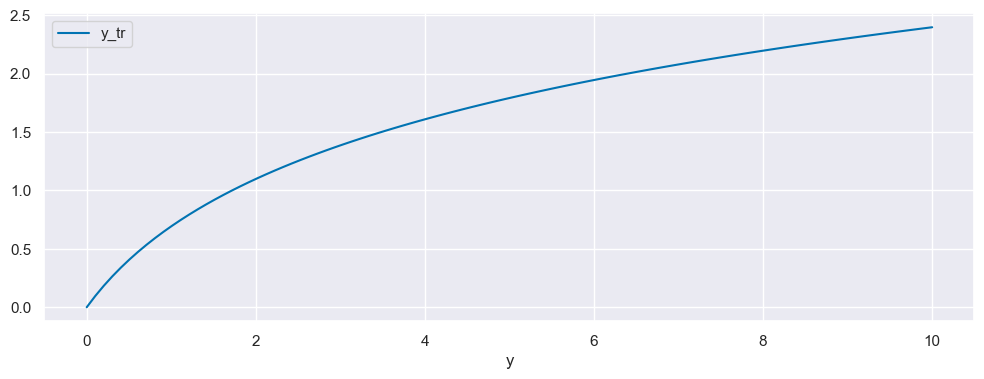

In [19]:
from sktime.transformations.series.boxcox import LogTransformer

y = np.linspace(0, 10, 100)

# Transforms each data point x to log(scale * (x + offset))
transformer = LogTransformer(scale=1, offset=1)

y_tr = transformer.fit_transform(y)

pd.DataFrame({"y": y, "y_tr": y_tr}).plot(x="y", y="y_tr", figsize=(12,4))

In [20]:
col = "unemp"

<Axes: xlabel='unemp', ylabel='Count'>

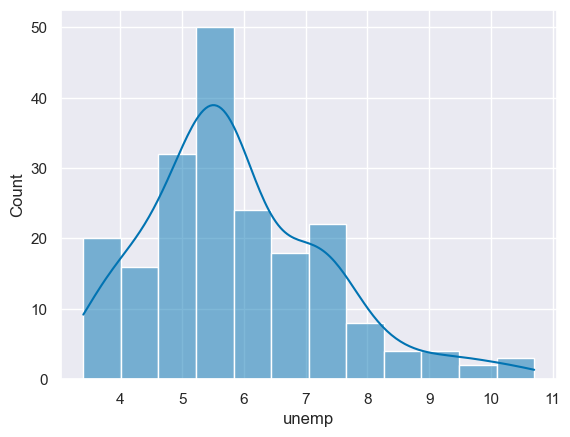

In [21]:
# normality of the distribution
sns.histplot(df[col], kde=True)

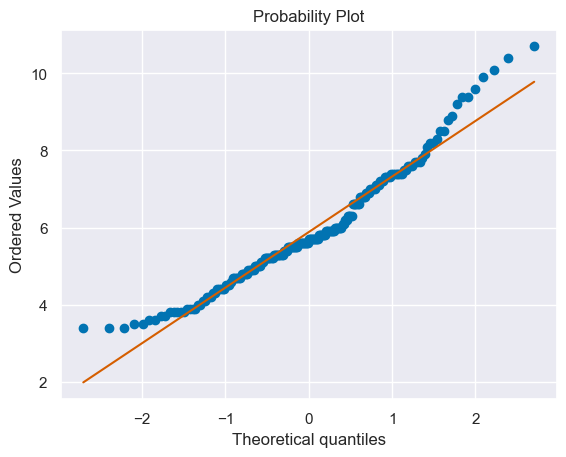

In [22]:
from scipy.stats import probplot

_ = probplot(df[col], dist='norm', plot=sns.mpl.pyplot)

In [23]:
from scipy.stats import shapiro 

# the null is that the data is normally distributed
stat, pval = shapiro(df[col])
print(f"Shapiro-Wilk test p-value: {pval:.3f}")

Shapiro-Wilk test p-value: 0.000


In [24]:
from sktime.transformations.series.boxcox import LogTransformer

transformer = LogTransformer(offset=0.001)
transformer.fit(df[col])
y_log_transformed = transformer.transform(df[col])

In [25]:
stat, pval = shapiro(y_log_transformed)
print(f"Shapiro-Wilk test p-value: {pval:.3f}")

Shapiro-Wilk test p-value: 0.092


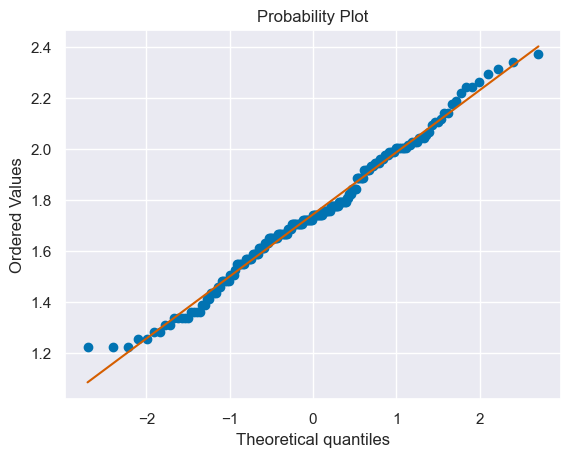

In [26]:
_ = probplot(y_log_transformed, dist='norm', plot=sns.mpl.pyplot)

<Axes: xlabel='unemp', ylabel='Count'>

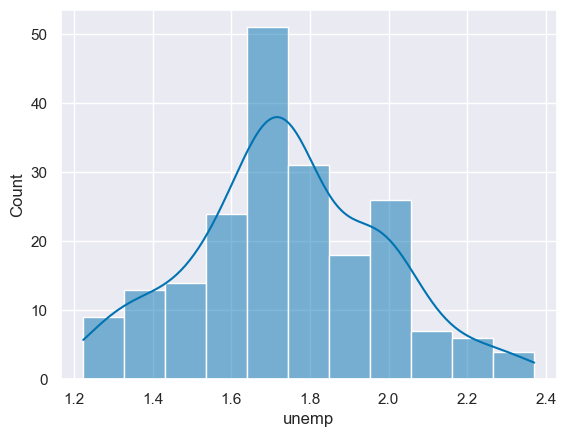

In [27]:
sns.histplot(y_log_transformed, kde=True)

## Box-Cox transformation

<Axes: xlabel='x'>

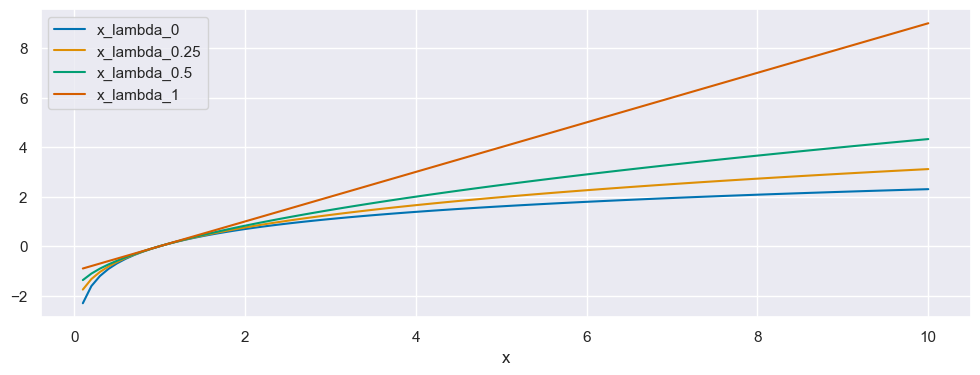

In [28]:
from sktime.transformations.series.boxcox import BoxCoxTransformer

tdf = pd.DataFrame({"x": np.linspace(0.1, 10, 100)})
for x in [0, 0.25, 0.5, 1]:
    transformer = BoxCoxTransformer(method="fixed", lambda_fixed=x)
    tdf[f"x_lambda_{x}"] = transformer.fit_transform(tdf["x"])

tdf.plot(x="x", y=[f"x_lambda_{x}" for x in [0, 0.25, 0.5, 1]], figsize=(12,4))

### Fixed lambda

In [29]:
# fixed lambda

from sktime.transformations.series.boxcox import BoxCoxTransformer

transformer = BoxCoxTransformer(method="fixed", lambda_fixed=0.5)
transformer.fit(df[col])
y_bc_transformed = transformer.transform(df[col])

<Axes: xlabel='unemp', ylabel='Count'>

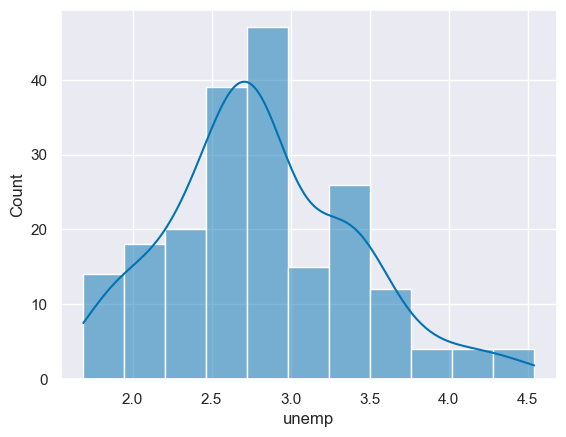

In [30]:
sns.histplot(y_bc_transformed, kde=True)

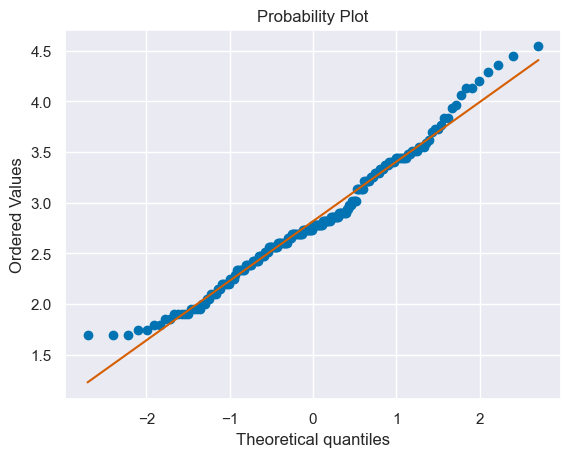

In [31]:
_ = probplot(y_bc_transformed, dist='norm', plot=sns.mpl.pyplot)

In [32]:
stat, pval = shapiro(y_bc_transformed)
print(f"Shapiro-Wilk test p-value: {pval:.3f}")

Shapiro-Wilk test p-value: 0.004


### Tuning lambda with pearsonr

In [33]:
# tuning the lambda parameter of the BoxCox transformation

from sktime.transformations.series.boxcox import BoxCoxTransformer

transformer = BoxCoxTransformer(method="pearsonr", bounds=(0, 5))
transformer.fit(df[col])
y_bc_transformed = transformer.transform(df[col])

In [34]:
transformer.lambda_

np.float64(5.517423354250251e-13)

<Axes: xlabel='unemp', ylabel='Count'>

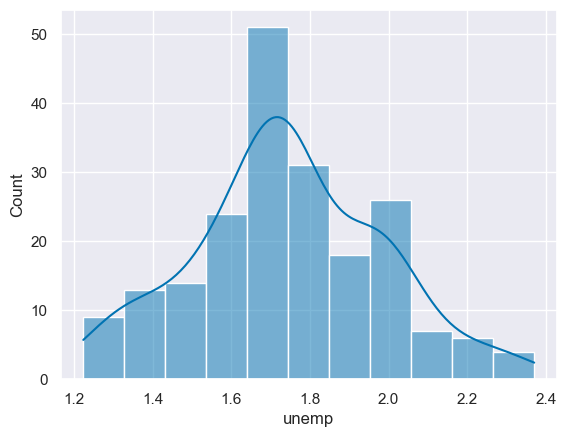

In [35]:
sns.histplot(y_bc_transformed, kde=True)

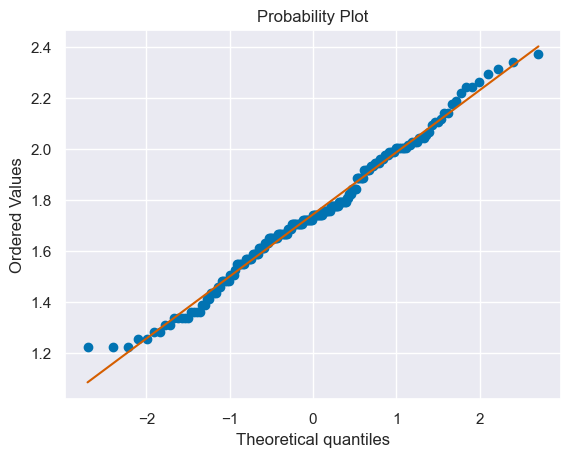

In [36]:
_ = probplot(y_bc_transformed, dist='norm', plot=sns.mpl.pyplot)

In [37]:
stat, pval = shapiro(y_bc_transformed)
print(f"Shapiro-Wilk test p-value: {pval:.3f}")

Shapiro-Wilk test p-value: 0.092


### Tuning lambda with mle

In [38]:
transformer = BoxCoxTransformer(method="mle", bounds=(0, 5))
transformer.fit(df[col])
y_bc_transformed = transformer.transform(df[col])

In [39]:
transformer.lambda_

np.float64(9.256139767886172e-08)

<Axes: xlabel='unemp', ylabel='Count'>

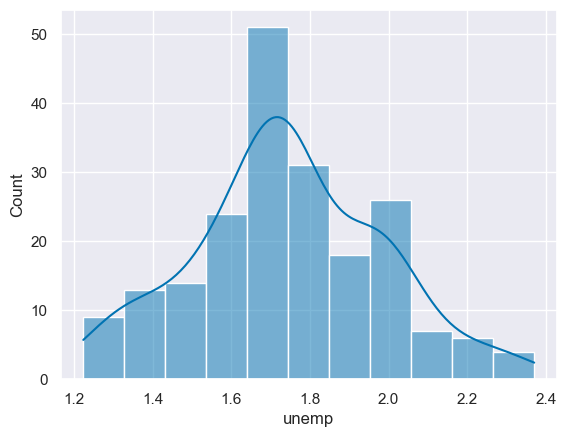

In [40]:
sns.histplot(y_bc_transformed, kde=True)

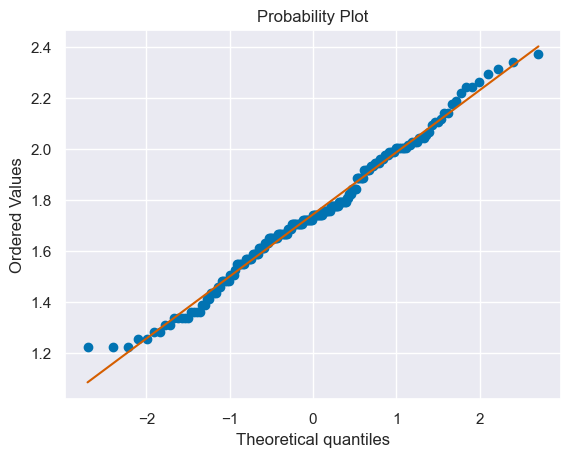

In [41]:
_ = probplot(y_bc_transformed, dist='norm', plot=sns.mpl.pyplot)

In [42]:
stat, pval = shapiro(y_bc_transformed)
print(f"Shapiro-Wilk test p-value: {pval:.3f}")

Shapiro-Wilk test p-value: 0.092


<Axes: xlabel='Period'>

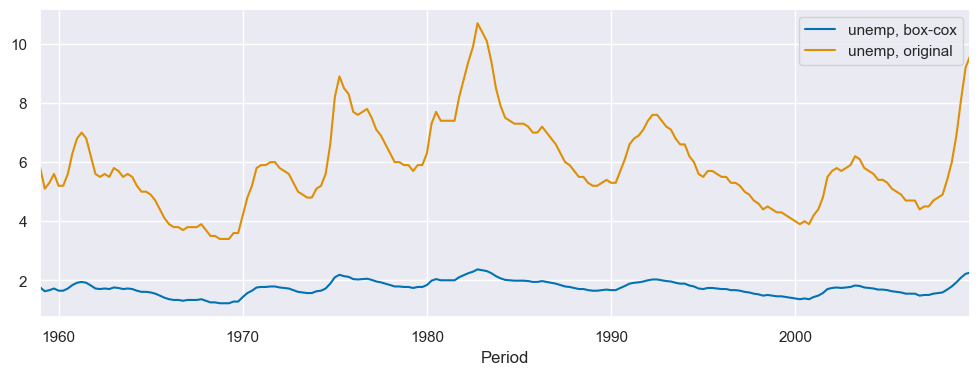

In [43]:
pd.DataFrame({f"{col}, box-cox": y_bc_transformed, f"{col}, original": df[col]}, index=df.index).plot(figsize=(12,4))  

# De-trending

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

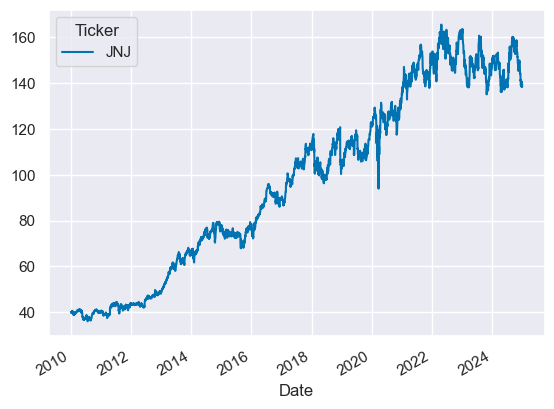

In [44]:
import yfinance as yf

# Define tickers
tickers = ["JNJ"]

# Download data and use only the close price
df = yf.download(
    tickers,
    start="2010-01-01",
    end="2025-01-01",
    interval="1d" # 1d
)["Close"]

# Extract only the Close prices
df.plot()

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2010-01-04 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   JNJ     3774 non-null   float64
dtypes: float64(1)
memory usage: 59.0 KB


<Axes: xlabel='Date'>

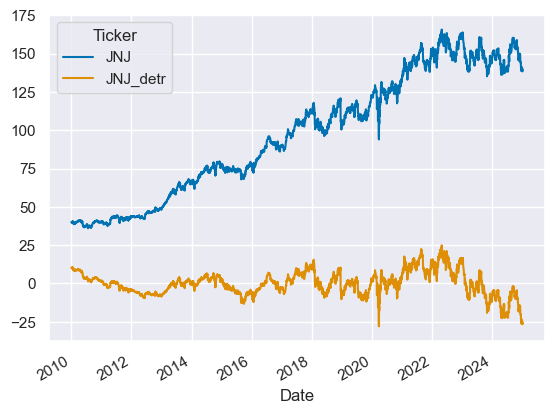

In [46]:
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.trend import PolynomialTrendForecaster

transformer = Detrender(forecaster=PolynomialTrendForecaster(degree=1))

transformer.fit(df["JNJ"])

df["JNJ_detr"] = transformer.transform(df["JNJ"])

df[["JNJ", "JNJ_detr"]].plot()

In [47]:
import pymannkendall as mk

mktest = mk.yue_wang_modification_test(df['JNJ_detr'], lag=4)
print(f"Trend: {mktest[0]}\np-value: {mktest[2]}")

Trend: no trend
p-value: 0.6639191655031171


# De-seasonalise via seasonal differencing

<Axes: >

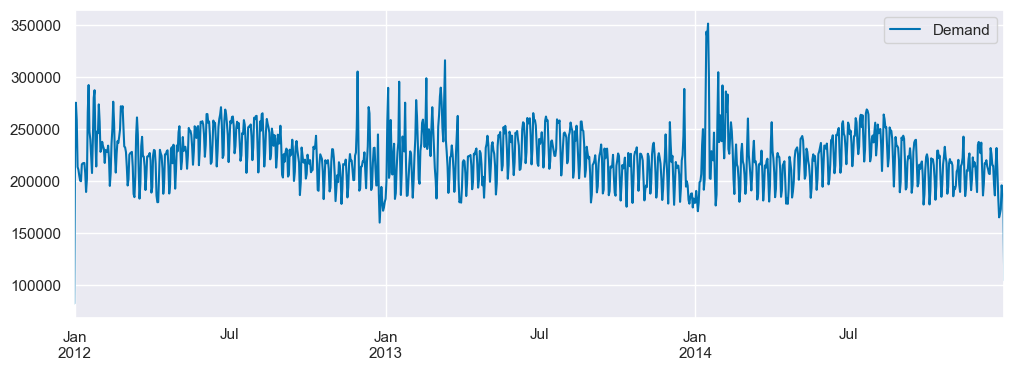

In [48]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/vic_electricity.csv",
                 parse_dates=["Time"], index_col="Time", usecols=["Time", "Demand"])
# remove the time zone information
df.index = pd.DatetimeIndex([i.replace(tzinfo=None) for i in df.index])

df = df.resample("D").sum()
df.index = df.index.to_period('D')

df.plot(figsize=(12,4))

<Axes: >

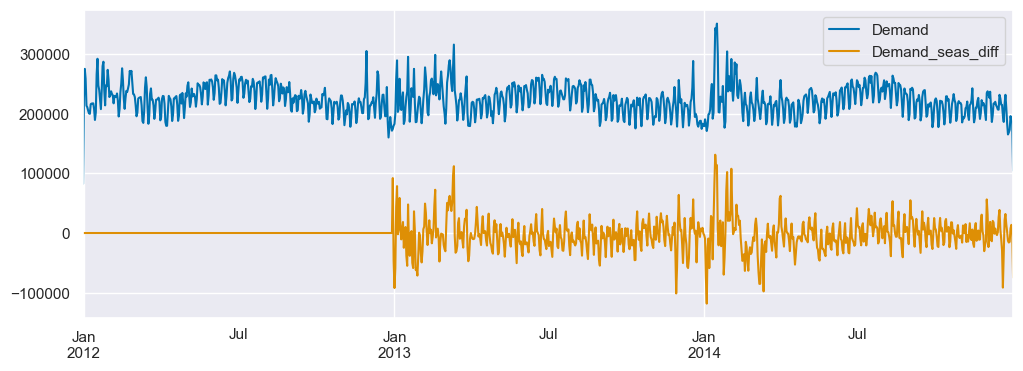

In [49]:
transformer = Differencer(lags=[365])
transformer.fit(df["Demand"])
df["Demand_seas_diff"] = transformer.transform(df["Demand"])

df.plot(figsize=(12,4))

# De-seasonalising with STL

<Axes: >

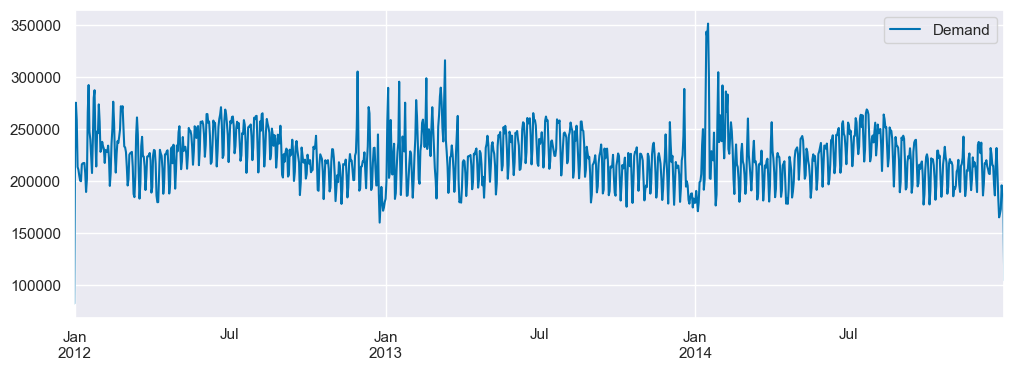

In [50]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/vic_electricity.csv",
                 parse_dates=["Time"], index_col="Time", usecols=["Time", "Demand"])
# remove the time zone information
df.index = pd.DatetimeIndex([i.replace(tzinfo=None) for i in df.index])

# aggregate into daily values
df = df.resample("D").sum()

df.plot(figsize=(12,4))

In [51]:
from sktime.transformations.series.detrend import STLTransformer

# Note: MSTL cannot transform a previously unseen series
stl = STLTransformer(sp=7, seasonal=31, trend=365)

stl.fit(df["Demand"])

# returns trend+residuals (default behaviour)
df["Demand_Deseason_7"] = stl.transform(df["Demand"])

<Axes: >

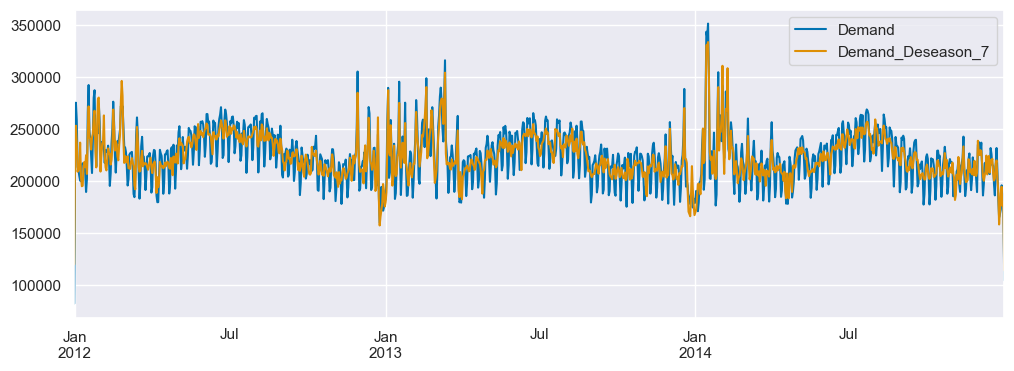

In [52]:
df.plot(figsize=(12,4))

In [53]:
# to extract components, without subtracting them

stl = STLTransformer(sp=7, seasonal=31, trend=365, return_components=True)

stl.fit(df["Demand"])

components = stl.transform(df["Demand"])

# the transformed column contains trend+resid
components

,transformed,seasonal,trend,resid
2011-12-31,120224.454066,-37692.708148,225872.283711,-105647.829645
2012-01-01,230740.396041,-2962.138737,225922.937616,4817.458425
2012-01-02,253370.197060,22120.791822,225973.545270,27396.651791
2012-01-03,236681.841267,22273.488155,226024.106498,10657.734770
2012-01-04,209235.880724,4556.496222,226074.620857,-16838.740133
...,...,...,...,...
2014-12-27,188558.641121,-15266.315449,207393.659754,-18835.018633
2014-12-28,194718.114954,1398.113938,207266.648618,-12548.533664
2014-12-29,176350.757896,12219.500400,207139.298324,-30788.540428
2014-12-30,179686.428815,7525.798031,207011.610649,-27325.181834


<Axes: >

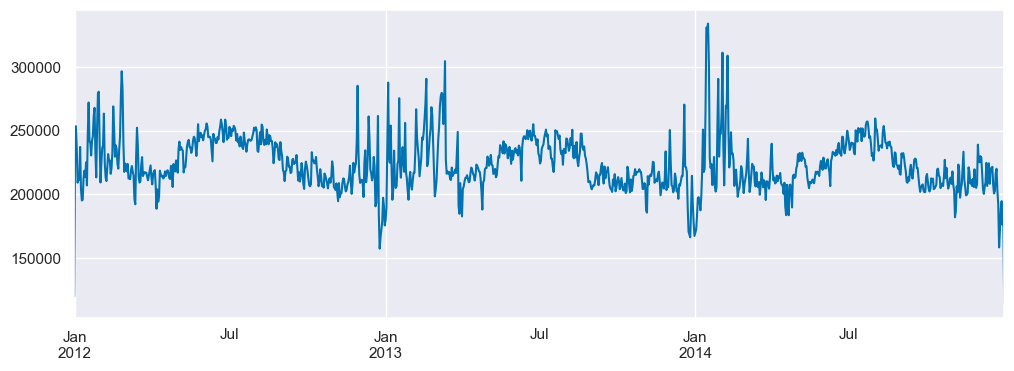

In [54]:
# inverse-transform
tdf = stl.inverse_transform(df["Demand_Deseason_7"])
tdf.plot(figsize=(12,4))

In [55]:
# remove also annual seasonality

stl = STLTransformer(sp=365, seasonal=5, trend=367)

stl.fit(df["Demand_Deseason_7"])

# returns trend+residuals
df["Demand_Deseason_365"] = stl.transform(df["Demand_Deseason_7"])

<Axes: >

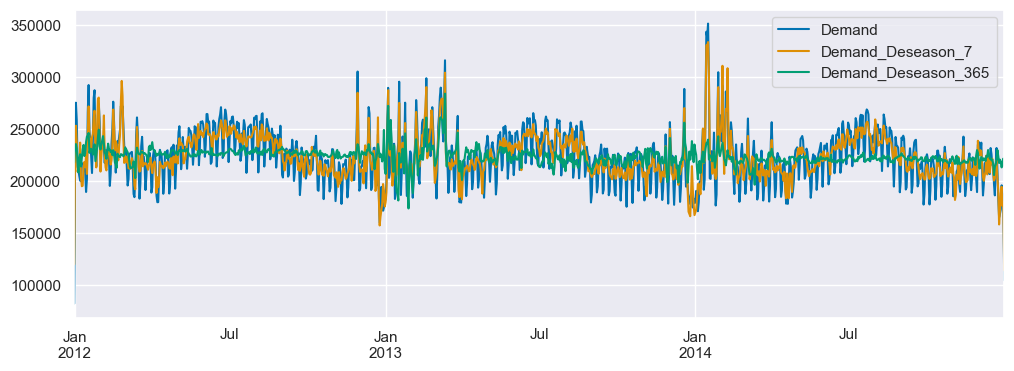

In [56]:
df.plot(figsize=(12,4))

# Handling outliers

## Rolling windows

<Axes: >

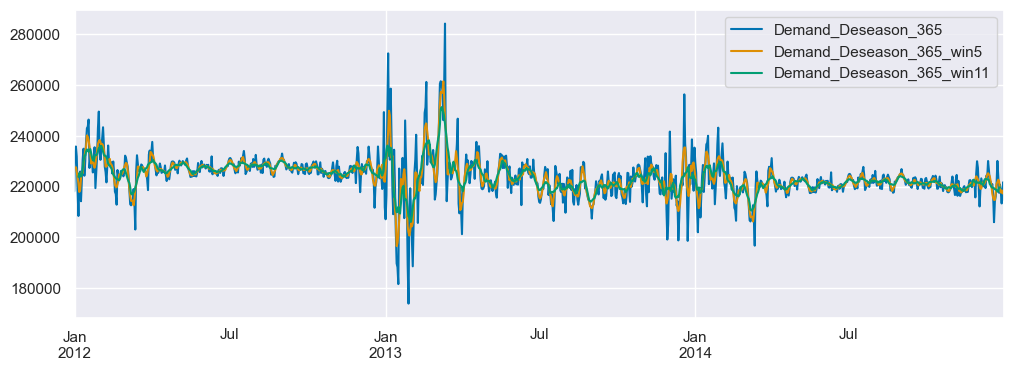

In [57]:
df["Demand_Deseason_365_win5"] = df["Demand_Deseason_365"].rolling(5, center=True).mean()
df["Demand_Deseason_365_win11"] = df["Demand_Deseason_365"].rolling(11, center=True).mean()
df[["Demand_Deseason_365", "Demand_Deseason_365_win5", "Demand_Deseason_365_win11"]].plot(figsize=(12,4))

## IQR and z-score

In [58]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.utils.validation import validate_data


class UnivariateOutlierDetector(TransformerMixin, BaseEstimator):

    def __init__(self, factor=1.5, method="iqr"):
        """Detect outliers in a univariate series using either the 
        IQR or the standard deviation method.
        Parameters
        ----------
        factor : float, default=1.5
            The factor to multiply the IQR or the standard deviation
            by to determine the outlier thresholds
        method : str, default="iqr"
            The method to use for outlier detection. Either "iqr" or 
            "zscore"
        """
        self.factor = factor
        self.method = method

    def fit(self, X, y=None):
        self._upper, self._lower = None, None
        if type(X) == pd.Series:
            X = X.values.reshape(-1, 1)
        X = validate_data(self, X)
        try:
            assert X.isnull().sum().sum() == 0
        except AttributeError:
            assert np.isnan(X).sum() == 0
        if self.method == "iqr":
            q25 = np.percentile(X, 25, axis=0)
            q75 = np.percentile(X, 75, axis=0)
            cut_off = (q75 - q25) * self.factor
            self._lower = q25 - cut_off
            self._upper = q75 + cut_off
        elif self.method == "zscore":
            mean = np.mean(X, axis=0)
            std = np.std(X, axis=0)
            self._lower = mean - self.factor * std
            self._upper = mean + self.factor * std
        self._is_fitted = True
        return self

    def predict(self, X, y=None):
        """Return True to indicate outliers, False to indicate inliers
        """
        check_is_fitted(self)
        if type(X) == pd.Series:
            X = X.values.reshape(-1, 1)
        X = validate_data(self, X, reset=False)
        return np.where(((X >= self._lower) & (X <= self._upper)), False, True)
    
    def transform(self, X, y=None):
        """Detect outliers and set them to np.nan
        """
        check_is_fitted(self)
        if type(X) == pd.Series:
            X = X.values.reshape(-1, 1)
        X = validate_data(self, X, reset=False)
        X = X.copy().astype('float')
        yhat = self.predict(X)
        X[yhat] = np.nan
        return X
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)
    
    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted
    

#from sklearn.utils.estimator_checks import check_estimator
#check_estimator(UnivariateOutlierDetector())

In [59]:
iqr_transformer = UnivariateOutlierDetector(method="iqr")
iqr_transformer.fit(df["Demand_Deseason_365"])
yhat = iqr_transformer.predict(df["Demand_Deseason_365"])

In [60]:
yhat.sum()

np.int64(57)

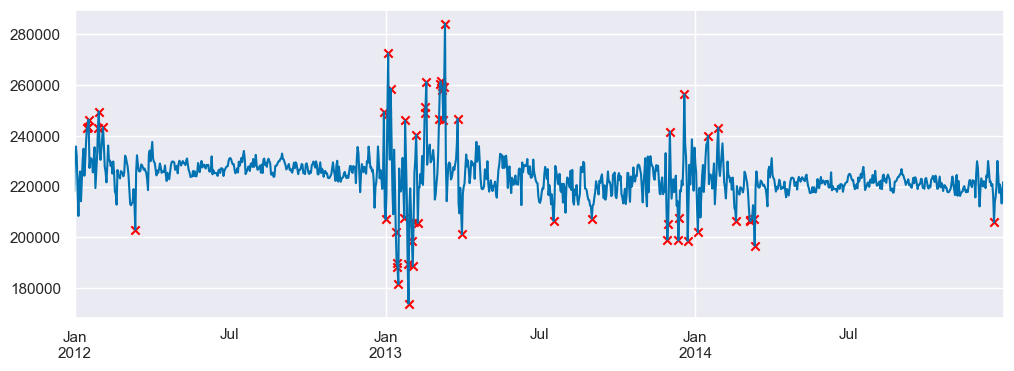

In [61]:
# plot

tdf = df["Demand_Deseason_365"].copy().sort_index()
tdf.plot(figsize=(12,4))
# display outliers only if they exist
if yhat.sum() > 0:
    outliers_df = df[yhat]
    plt.scatter(
        x=outliers_df.index,
        y=outliers_df["Demand_Deseason_365"],
        marker='x',
        color="red"
    )
    plt.show()

## STRAY

In [62]:
# https://www.sktime.net/en/v0.40.1/api_reference/auto_generated/sktime.detection.stray.STRAY.html
# Original paper: https://arxiv.org/pdf/1908.04000 

from sklearn.preprocessing import MinMaxScaler
from sktime.detection.stray import STRAY

X = df["Demand_Deseason_365"].values.reshape(-1, 1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
stray_transformer = STRAY(k=5, alpha=0.05) # greater alpha - more aggressive outlier detection
stray_transformer.fit(X)
yhat = stray_transformer.transform(X)
yhat.sum()

np.int64(0)

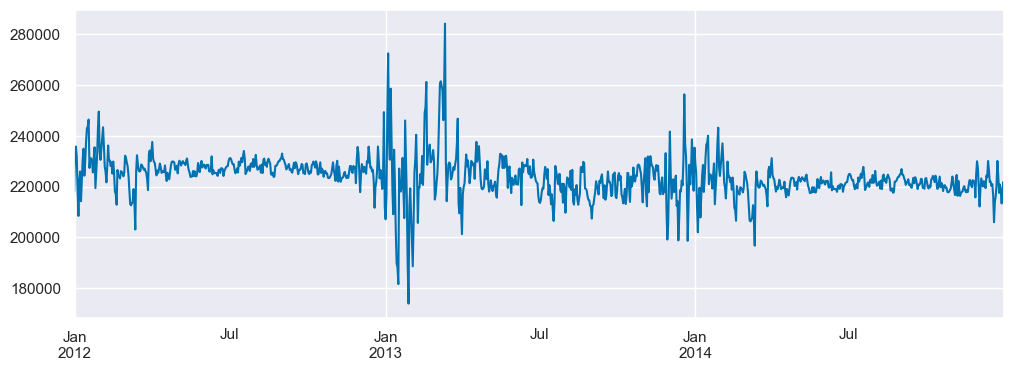

In [63]:
# plot
tdf = df["Demand_Deseason_365"].copy().sort_index()

# display outliers only if they exist
tdf.plot(figsize=(12,4))
if yhat.sum() > 0:
    outliers_df = df[yhat]
    plt.scatter(
        x=outliers_df.index,
        y=outliers_df["Demand_Deseason_365"],
        marker='x',
        color="red"
    )
    plt.show()

In [64]:
# use the IQR transformer for detection and eventual removal of outliers
df["Demand_Deseason_365"] = iqr_transformer.transform(df["Demand_Deseason_365"])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1097 entries, 2011-12-31 to 2014-12-31
Freq: D
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Demand                     1097 non-null   float64
 1   Demand_Deseason_7          1097 non-null   float64
 2   Demand_Deseason_365        1040 non-null   float64
 3   Demand_Deseason_365_win5   1093 non-null   float64
 4   Demand_Deseason_365_win11  1087 non-null   float64
dtypes: float64(5)
memory usage: 51.4 KB


# Imputer

In [65]:
from sktime.transformations.series.impute import Imputer

In [66]:
transformer = Imputer(method="linear") # mean, backfill, ffill, forecaster
transformer.fit(df["Demand_Deseason_365"])

df["Demand_Deseason_365"] = transformer.transform(df["Demand_Deseason_365"])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1097 entries, 2011-12-31 to 2014-12-31
Freq: D
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Demand                     1097 non-null   float64
 1   Demand_Deseason_7          1097 non-null   float64
 2   Demand_Deseason_365        1097 non-null   float64
 3   Demand_Deseason_365_win5   1093 non-null   float64
 4   Demand_Deseason_365_win11  1087 non-null   float64
dtypes: float64(5)
memory usage: 51.4 KB


# Transformer pipeline

<Axes: >

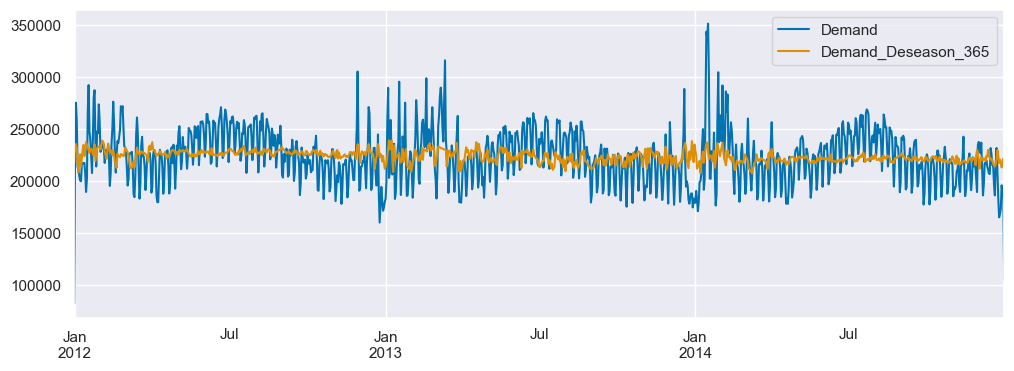

In [67]:
df[["Demand", "Demand_Deseason_365"]].plot(figsize=(12,4))

In [68]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/vic_electricity.csv",
                 parse_dates=["Time"], index_col="Time", usecols=["Time", "Demand"])
# remove the time zone information
df.index = pd.DatetimeIndex([i.replace(tzinfo=None) for i in df.index])

# aggregate into daily values
df = df.resample("D").sum()

In [69]:
from sktime.transformations.series.detrend import STLTransformer
from sktime.transformations.compose import TransformerPipeline

pipe = TransformerPipeline(
        steps = [
            ("weekly", STLTransformer(sp=7, seasonal=31, trend=365)),
            ("annual", STLTransformer(sp=365, seasonal=31, trend=367)),
            ("outlier_detector", UnivariateOutlierDetector(factor=1.5, method="iqr")),
            ("imputer", Imputer(method="linear"))
        ]
    )

pipe.fit(df["Demand"])
df["Demand_transformed"] = pipe.transform(df["Demand"])

<Axes: >

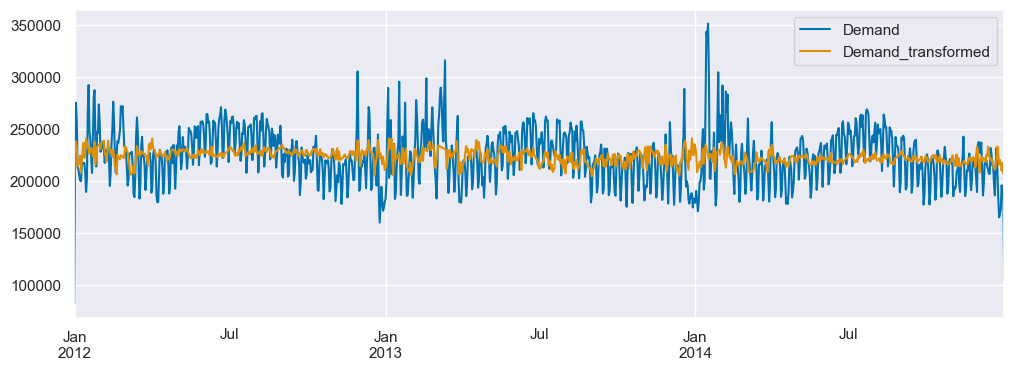

In [70]:
df.plot(figsize=(12, 4))

# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf